In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Downloads//_MConverter.eu_aerofit_treadmill (1).csv")
data

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [6]:
data['Product'].value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [6]:
Quartiles = data['Income'].quantile([0.25, 0.5, 0.75, 1])
Quartiles

0.25     44058.75
0.50     50596.50
0.75     58668.00
1.00    104581.00
Name: Income, dtype: float64

<Axes: xlabel='Income'>

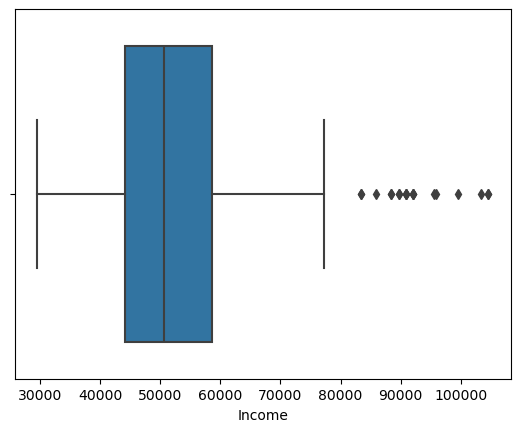

In [7]:
sns.boxplot(x = data['Income'])

<Axes: xlabel='Miles'>

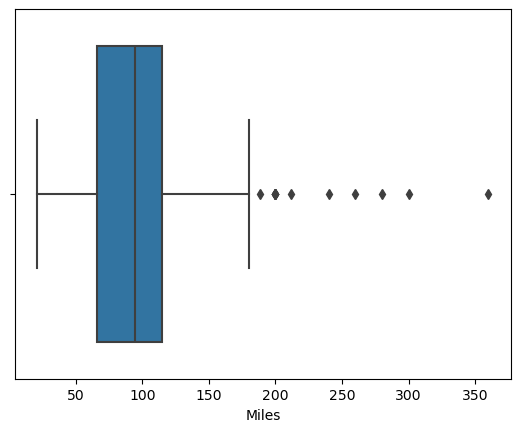

In [8]:
sns.boxplot(x = data['Miles'])

<Axes: xlabel='Usage'>

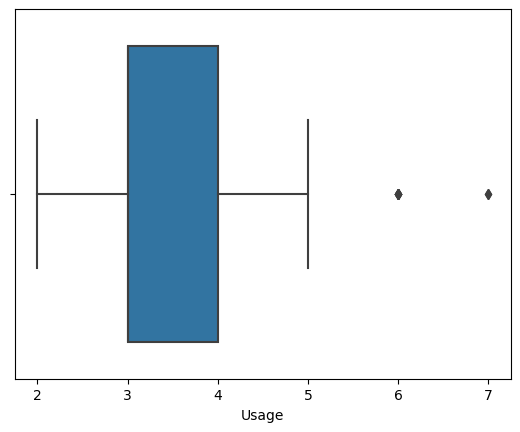

In [9]:
sns.boxplot(x = data['Usage'])

## Marital status and product purchaged 

<Axes: xlabel='Product', ylabel='count'>

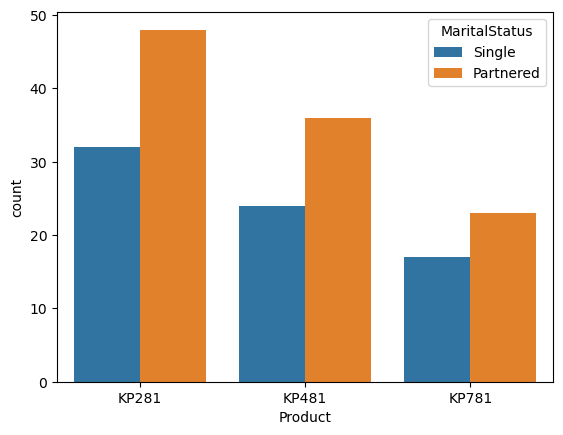

In [10]:
sns.countplot(x = 'Product', hue = 'MaritalStatus', data = data)

## Age vs product purchaged

<Axes: xlabel='Product', ylabel='Age'>

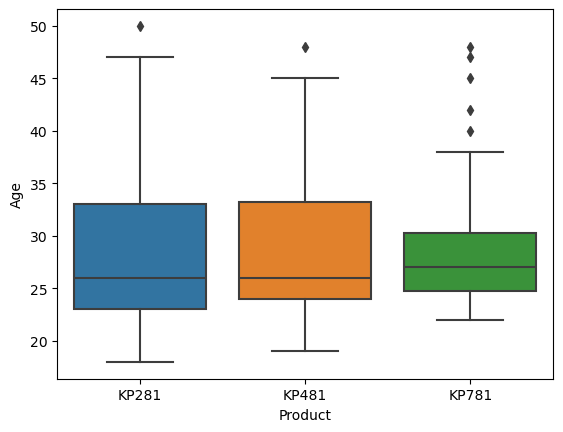

In [19]:
sns.boxplot(x = 'Product', y = 'Age', data = data)

In [ ]:
##All three products attract customers of roughly the same median age (~26–27), so age alone doesn't strongly differentiate buyer preference.
##KP781 buyers are more age-homogeneous — Its box is much narrower, meaning buyers cluster tightly around the median. KP281 and KP481 attract a much wider age range.
##KP781 has more high-age outliers — Several customers aged 40–49 bought KP781, suggesting it occasionally appeals to an older niche despite the compact core distribution.
##KP281 has the widest spread — It attracts the broadest range of ages, possibly making it the most "general purpose" product.

## Representing the marginal probability, like, what percent of customers have purchased KP281, KP481, or KP781

In [21]:
marginal_prob = pd.crosstab(index=data['Product'], 
                            columns='Percentage', 
                            normalize=True) * 100

print(marginal_prob)

col_0    Percentage
Product            
KP281     44.444444
KP481     33.333333
KP781     22.222222


In [13]:
pd.crosstab(data['Product'], data['Gender'], normalize='index')


Gender,Female,Male
Product,,
KP281,0.500000,0.500000
KP481,0.483333,0.516667
KP781,0.175000,0.825000


In [14]:
pd.crosstab(data['Product'], data['Gender'], normalize='columns')


Gender,Female,Male
Product,,
KP281,0.526316,0.384615
KP481,0.381579,0.298077
KP781,0.092105,0.317308


In [15]:
pd.crosstab(data['Product'], data['Gender'], normalize=True)

Gender,Female,Male
Product,,
KP281,0.222222,0.222222
KP481,0.161111,0.172222
KP781,0.038889,0.183333


## correlation among different factors using heat maps or pair plots.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encode categorical columns to numeric for correlation
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Make a copy to avoid modifying original data
df_encoded = data.copy()

# Encode categorical columns
categorical_cols = ['Product', 'Gender', 'MaritalStatus', 'Education']
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Select only your required columns
columns = ['Product', 'Age', 'Gender', 'Education', 
           'MaritalStatus', 'Usage', 'Fitness', 'Income', 'Miles']

df_selected = df_encoded[columns]

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,0,18,1,2,1,3,4,29562,112
1,0,19,1,3,1,2,3,31836,75
2,0,19,0,2,0,4,3,30699,66
3,0,19,1,0,1,3,3,32973,85
4,0,20,1,1,0,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,2,40,1,7,1,6,5,83416,200
176,2,42,1,5,1,5,4,89641,200
177,2,45,1,4,1,5,5,90886,160
178,2,47,1,5,0,4,5,104581,120


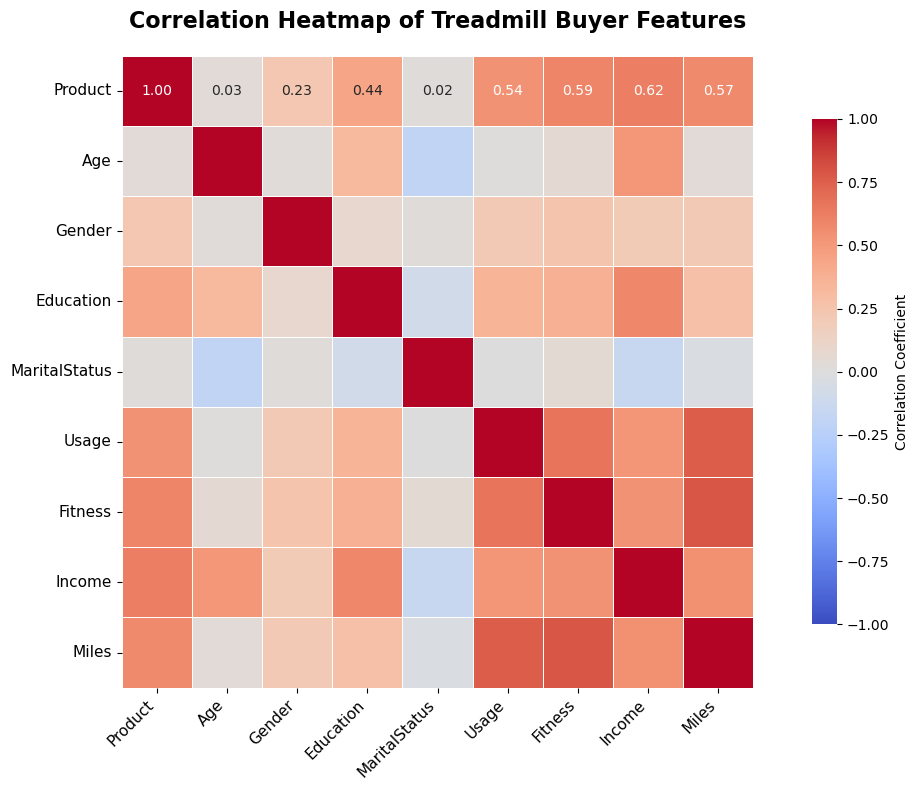


--- Correlation with Product ---
Product          1.000000
Income           0.624168
Fitness          0.594883
Miles            0.571596
Usage            0.537447
Education        0.438425
Gender           0.230653
Age              0.032225
MaritalStatus    0.017602
Name: Product, dtype: float64


In [18]:
plt.figure(figsize=(12, 8))

# Calculate correlation matrix
corr_matrix = df_selected.corr()

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=True,           # Show correlation values inside cells
    fmt='.2f',            # Round to 2 decimal places
    cmap='coolwarm',      # Color: blue=negative, red=positive
    center=0,             # Center color scale at 0
    vmin=-1, vmax=1,      # Correlation range
    square=True,          # Make cells square
    linewidths=0.5,       # Grid line width
    linecolor='white',    # Grid line color
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Treadmill Buyer Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# Print correlation with Product specifically
print("\n--- Correlation with Product ---")
print(corr_matrix['Product'].sort_values(ascending=False))

In [ ]:
# Bar chart of correlation strengths with Product
plt.figure(figsize=(10, 5))

product_corr = corr_matrix['Product'].drop('Product').sort_values()

colors = ['#d73027' if x < 0 else '#1a9850' for x in product_corr]

bars = plt.barh(product_corr.index, product_corr.values, color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, product_corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', 
             ha='left' if val >= 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Product', fontsize=14, fontweight='bold')
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\maham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

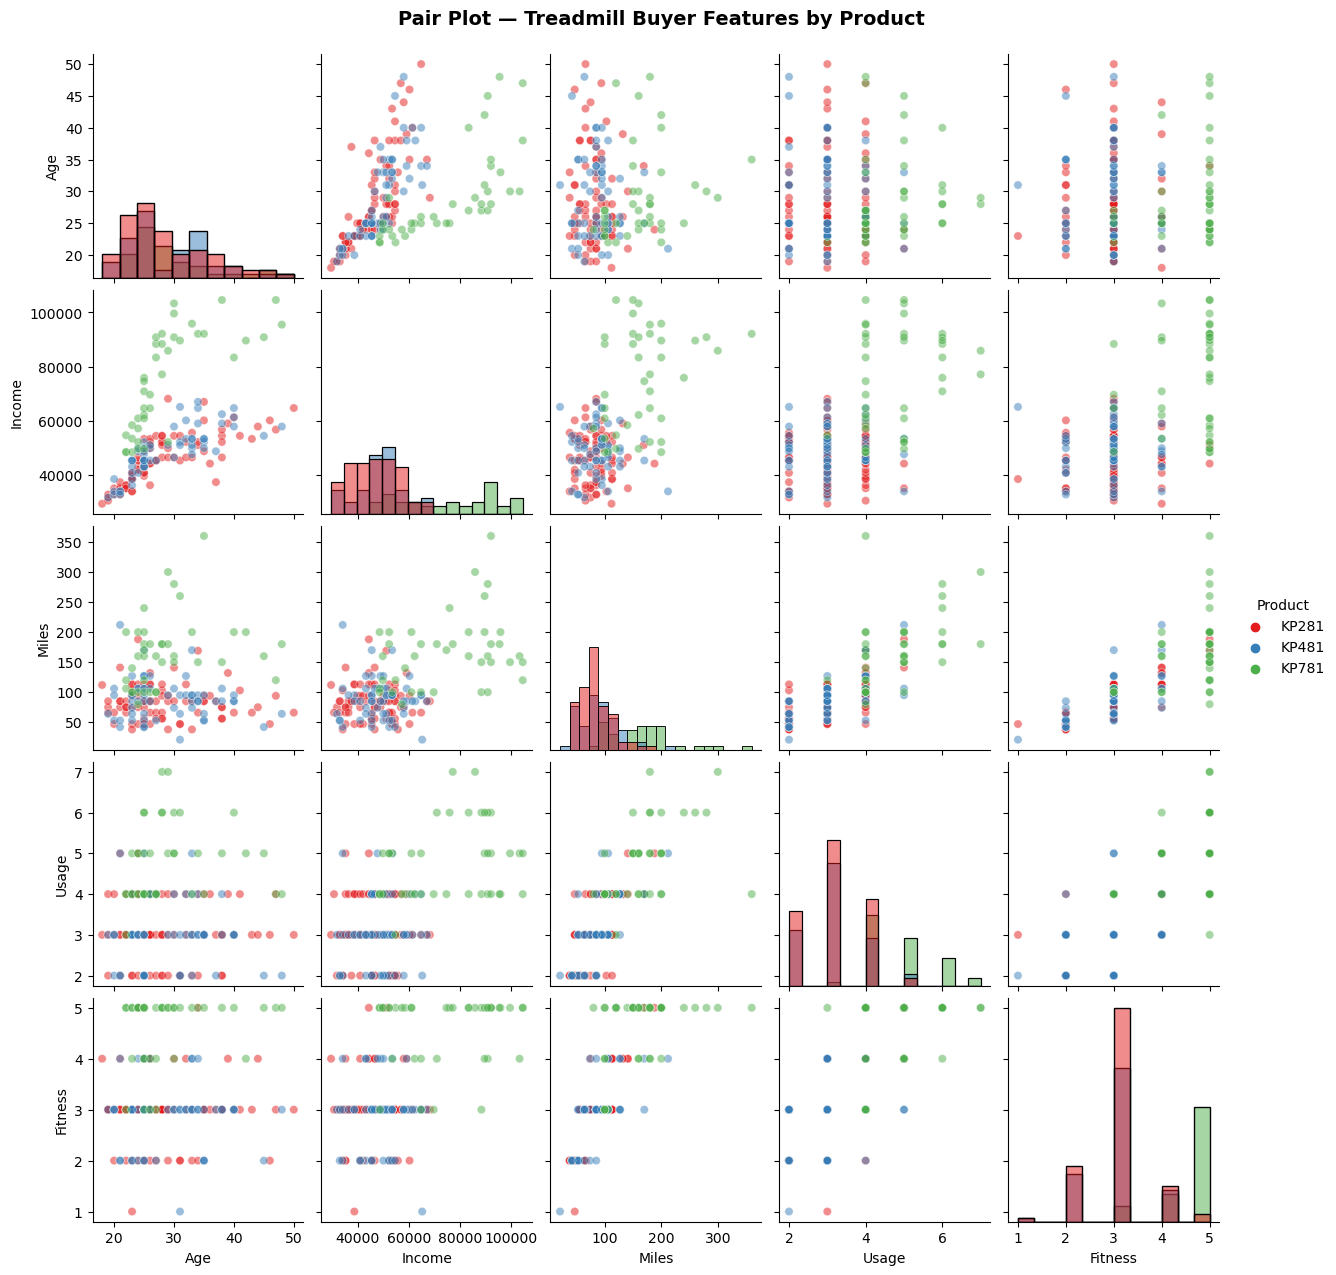

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Clean dataframe
df_pair = data[['Age', 'Income', 'Miles', 'Usage', 'Fitness', 'Product']].copy()
df_pair[['Age','Income','Miles','Usage','Fitness']] = \
    df_pair[['Age','Income','Miles','Usage','Fitness']].apply(pd.to_numeric, errors='coerce')
df_pair['Product'] = df_pair['Product'].astype(str)
df_pair.dropna(inplace=True)

# Safest pairplot — no version-specific params
g = sns.pairplot(
    df_pair,
    hue='Product',
    vars=['Age', 'Income', 'Miles', 'Usage', 'Fitness'],
    diag_kind='hist',          # ✅ 'hist' is safer than 'kde' across versions
    plot_kws={'alpha': 0.5},
    palette='Set1'
)

g.fig.suptitle('Pair Plot — Treadmill Buyer Features by Product',
               fontsize=14, fontweight='bold', y=1.02)
plt.show()

## What is the probability of a male customer buying a KP781 treadmill?

In [8]:
data.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [40]:
Male_cus = data[data['Gender'] == 'Male']['Gender'].count()
Male_cus

104

In [56]:
# 1. Count all male customers
Male_cus = data[data['Gender'] == 'Male']['Gender'].count()

Model = data[(data['Gender'] == 'Male') & (data['Product'] == 'KP781')]['Product'].count()

Prob = (Model / Male_cus) * 100

print(f"Probability: {Prob:.2f}%")

Probability: 31.73%


Customer Profiling — Categorization of Users

In [4]:
# Average profile of each product's customer
product_profile = data.groupby('Product').agg({
    'Age'          : ['mean', 'median', 'min', 'max'],
    'Income'       : ['mean', 'median', 'min', 'max'],
    'Miles'        : ['mean', 'median'],
    'Usage'        : ['mean', 'median'],
    'Fitness'      : ['mean', 'median'],
    'Education'    : ['mean']
}).round(2)

print("--- Product-wise Customer Profile ---")
print(product_profile)



--- Product-wise Customer Profile ---
           Age                   Income                           Miles  \
          mean median min max      mean   median    min     max    mean   
Product                                                                   
KP281    28.55   26.0  18  50  46418.02  46617.0  29562   68220   82.79   
KP481    28.90   26.0  19  48  48973.65  49459.5  31836   67083   87.93   
KP781    29.10   27.0  22  48  75441.58  76568.5  48556  104581  166.90   

               Usage        Fitness        Education  
        median  mean median    mean median      mean  
Product                                               
KP281     85.0  3.09    3.0    2.96    3.0     15.04  
KP481     85.0  3.07    3.0    2.90    3.0     15.12  
KP781    160.0  4.78    5.0    4.62    5.0     17.32  


In [8]:
# Create income buckets
data['IncomeGroup'] = pd.cut(
    data['Income'],
    bins=[0, 40000, 60000, 80000, 200000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Age groups
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[0, 25, 35, 45, 100],
    labels=['Young (≤25)', 'Mid (26-35)', 'Senior (36-45)', 'Older (45+)']
)

# Fitness segments
data['FitnessLevel'] = pd.cut(
    data['Fitness'],
    bins=[0, 2, 3, 5],
    labels=['Low', 'Moderate', 'High']
)

print(data[['Product', 'IncomeGroup', 'AgeGroup', 'FitnessLevel']].head(5))

  Product IncomeGroup     AgeGroup FitnessLevel
0   KP281         Low  Young (≤25)         High
1   KP281         Low  Young (≤25)     Moderate
2   KP281         Low  Young (≤25)     Moderate
3   KP281         Low  Young (≤25)     Moderate
4   KP281         Low  Young (≤25)          Low


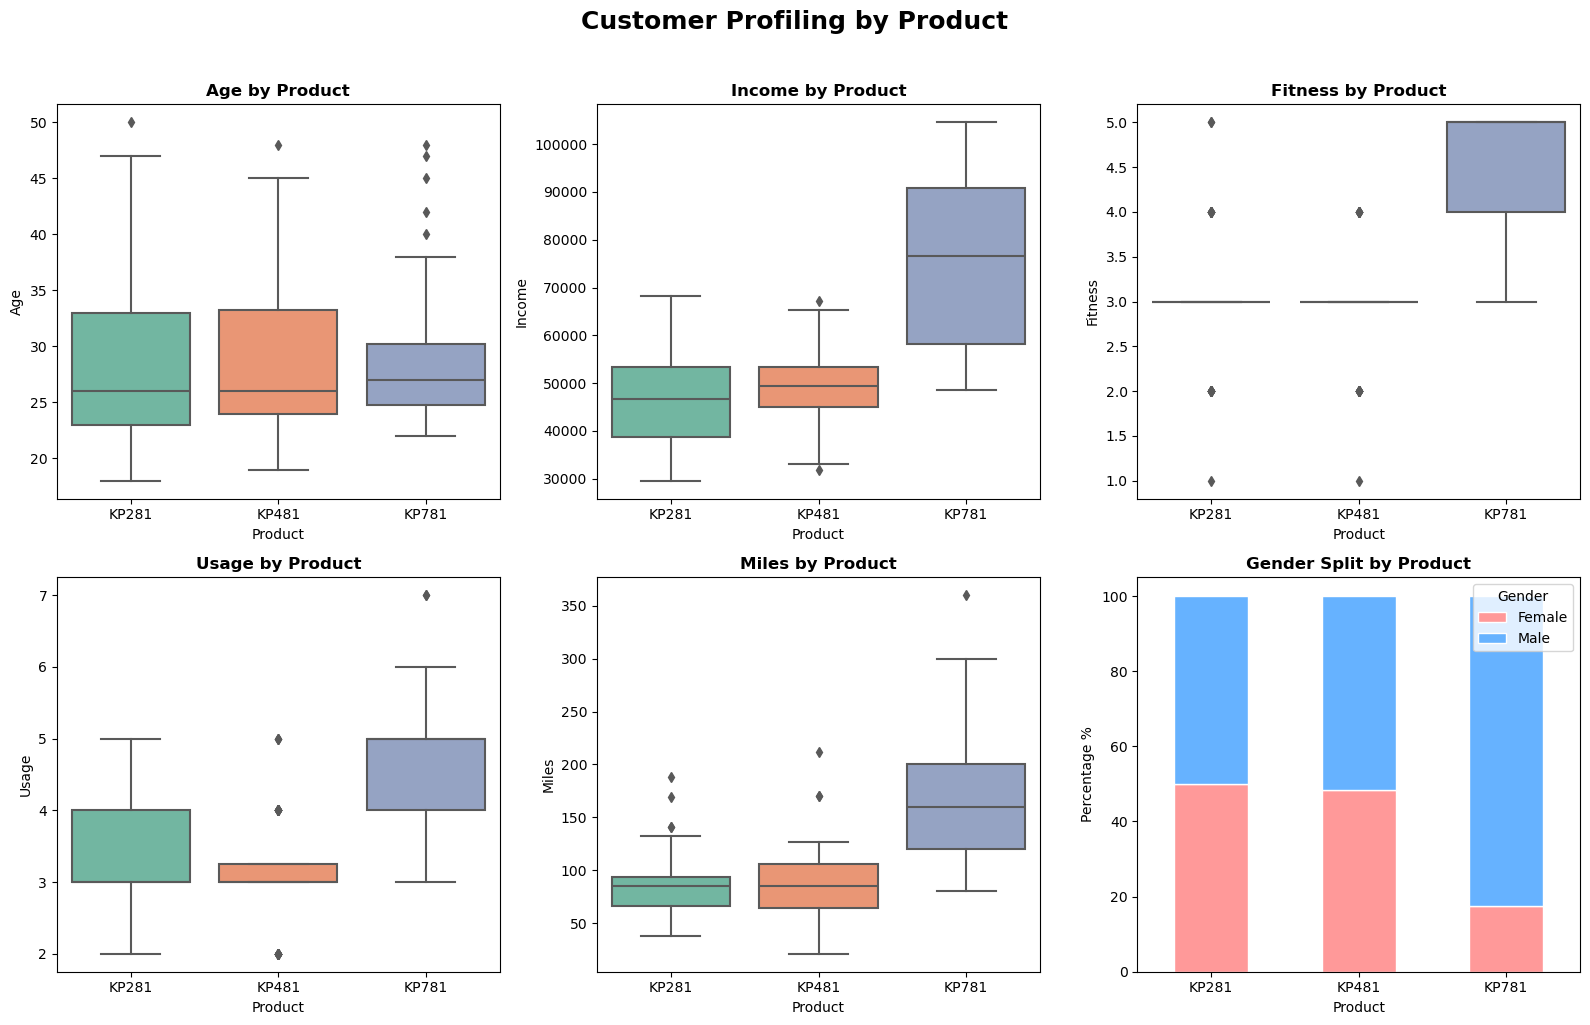

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Profiling by Product', 
             fontsize=18, fontweight='bold', y=1.02)

numeric_features = {
    'Age'    : axes[0, 0],
    'Income' : axes[0, 1],
    'Fitness': axes[0, 2],
    'Usage'  : axes[1, 0],
    'Miles'  : axes[1, 1]
}

# Boxplot for each numeric feature
for feature, ax in numeric_features.items():
    sns.boxplot(x='Product', y=feature, data=data, palette='Set2', ax=ax)
    ax.set_title(f'{feature} by Product', fontweight='bold')
    ax.set_xlabel('Product')

# Gender split stacked bar
gender_pct = pd.crosstab(data['Product'], data['Gender'], normalize='index') * 100
gender_pct.plot(kind='bar', stacked=True, ax=axes[1, 2], color=['#FF9999', '#66B2FF'], edgecolor='white')
axes[1, 2].set_title('Gender Split by Product', fontweight='bold')
axes[1, 2].set_xlabel('Product')
axes[1, 2].set_ylabel('Percentage %')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Gender')

plt.tight_layout()
plt.show()
fig, axes = plt.subplot(2,3, figsize= (16,10)
                        

In [8]:
# Summary table for heatmap
profile_summary = data.groupby('Product')[
    ['Age', 'Income', 'Fitness', 'Usage', 'Miles', 'Education']
].mean().round(2)

# Normalize each column 0-1 for fair visual comparison
profile_normalized = (profile_summary - profile_summary.min()) / \ (profile_summary.max() - profile_summary.min())

plt.figure(figsize=(10, 4))
sns.heatmap(
    profile_normalized,
    annot=profile_summary.values,   # Show actual values
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Relative Scale (0=Low, 1=High)'}
)
plt.title('Customer Profile Comparison Across Products',
          fontsize=14, fontweight='bold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

SyntaxError: unexpected character after line continuation character (3083745963.py, line 7)

Probability- marginal, conditional probability.

In [6]:
print("=" * 50)
print("        MARGINAL PROBABILITIES")
print("=" * 50)

# 1. Product
product_marginal = data['Product'].value_counts(normalize=True).round(4) * 100
print("\n--- P(Product) ---")
for product, prob in product_marginal.items():
    print(f"   P({product}) = {prob:.2f}%")

# 2. Gender
gender_marginal = data['Gender'].value_counts(normalize=True).round(4) * 100
print("\n--- P(Gender) ---")
for gender, prob in gender_marginal.items():
    print(f"   P({gender}) = {prob:.2f}%")

# 3. MaritalStatus
marital_marginal = data['MaritalStatus'].value_counts(normalize=True).round(4) * 100
print("\n--- P(MaritalStatus) ---")
for status, prob in marital_marginal.items():
    print(f"   P({status}) = {prob:.2f}%")

# 4. Income Group
income_marginal = data['Income'].value_counts(normalize=True).round(4) * 100
print("\n--- P(IncomeGroup) ---")
for group, prob in income_marginal.items():
    print(f"   P({group} Income) = {prob:.2f}%")

# 5. Fitness Level
fitness_marginal = data['Fitness'].value_counts(normalize=True).round(4) * 100
print("\n--- P(FitnessLevel) ---")
for level, prob in fitness_marginal.items():
    print(f"   P({level} Fitness) = {prob:.2f}%")

        MARGINAL PROBABILITIES

--- P(Product) ---
   P(KP281) = 44.44%
   P(KP481) = 33.33%
   P(KP781) = 22.22%

--- P(Gender) ---
   P(Male) = 57.78%
   P(Female) = 42.22%

--- P(MaritalStatus) ---
   P(Partnered) = 59.44%
   P(Single) = 40.56%

--- P(IncomeGroup) ---
   P(45480 Income) = 7.78%
   P(52302 Income) = 5.00%
   P(46617 Income) = 4.44%
   P(54576 Income) = 4.44%
   P(53439 Income) = 4.44%
   P(50028 Income) = 3.89%
   P(51165 Income) = 3.89%
   P(40932 Income) = 3.33%
   P(48891 Income) = 2.78%
   P(32973 Income) = 2.78%
   P(35247 Income) = 2.78%
   P(38658 Income) = 2.78%
   P(34110 Income) = 2.78%
   P(43206 Income) = 2.78%
   P(57987 Income) = 2.22%
   P(44343 Income) = 2.22%
   P(36384 Income) = 2.22%
   P(64809 Income) = 1.67%
   P(90886 Income) = 1.67%
   P(60261 Income) = 1.67%
   P(92131 Income) = 1.67%
   P(59124 Income) = 1.67%
   P(88396 Income) = 1.11%
   P(49801 Income) = 1.11%
   P(83416 Income) = 1.11%
   P(64741 Income) = 1.11%
   P(61006 Income) = 1.11%

In [13]:
print("=" * 60)
print("     RECOMMENDATIONS & ACTIONABLE INSIGHTS")
print("=" * 60)

# ── Insight 1: Product Popularity ───────────────────
print("\INSIGHT 1 — Product Demand")
print("-" * 60)
for product, pct in product_marginal.items():
    print(f"   {product}: {pct:.1f}% of total sales")

print("""
Recommendation:
   → KP281 drives majority of sales — ensure strong inventory
   → KP781 has smallest share but likely highest margin
   → KP481 is middle ground — good upsell target from KP281
""")


# ── Insight 2: Income Drives Premium Purchase ────────
print(" INSIGHT 2 — Income & Product Choice")
print("-" * 60)
income_avg = data.groupby('Product')['Income'].mean()
for product, income in income_avg.items():
    print(f"   Avg Income of {product} buyers: ${income:,.0f}")

print("""
   Recommendation:
   → Target KP781 marketing at income > $60k segments
   → Offer EMI / financing options for KP281 buyers
     (lower income group) to increase conversion
   → KP481 sits in middle — highlight value-for-money
""")


# ── Insight 3: Fitness & Usage Behavior ─────────────
print(" INSIGHT 3 — Fitness & Usage Patterns")
print("-" * 60)
fitness_usage = data.groupby('Product')[['Fitness','Usage','Miles']].mean()
print(fitness_usage.round(2).to_string())

print("""
Recommendation:
   → KP781 buyers are serious athletes (high fitness + miles)
     → Market through fitness apps, gyms, running communities
   → KP281 buyers are casual users
     → Focus on ease-of-use, beginner-friendly messaging
   → KP481 buyers are intermediate
     → Highlight performance upgrade features
""")


# ── Insight 4: Gender Gap ────────────────────────────
print("INSIGHT 4 — Gender Distribution")
print("-" * 60)
gender_split = pd.crosstab(data['Product'], data['Gender'])
print(gender_split)

print("""
Recommendation:
   → If males dominate KP781 — create female-targeted
     campaigns emphasizing endurance & performance
   → Gender-balanced products (KP281) need neutral messaging
   → Consider female-specific features in next product version
""")


# ── Insight 5: Marital Status ────────────────────────
print("\nINSIGHT 5 — Marital Status Impact")
print("-" * 60)
marital_split = pd.crosstab(data['Product'], 
                             data['MaritalStatus'],
                             normalize='index').round(3) * 100
print(marital_split.to_string())

print(""" Recommendation:
   → If partnered customers dominate — offer couples
     fitness packages or dual-user treadmill plans
   → Single customers may respond to personal
     achievement and solo fitness goal messaging
""")


# ── Insight 6: High Value Customer Segment ──────────
print("\nINSIGHT 6 — High Value Customer Profile")
print("-" * 60)

# Identify highest value segment
high_value = data[
    (data['Product'] == 'KP781') &
    (data['Income']  >  data['Income'].quantile(0.75))
]

print(f"   High Value Customers (KP781 + Top 25% Income): "
      f"{len(high_value)} customers")
print(f"   Avg Miles   : {high_value['Miles'].mean():.1f}")
print(f"   Avg Fitness : {high_value['Fitness'].mean():.1f}")
print(f"   Avg Usage   : {high_value['Usage'].mean():.1f} days/week")

print("""
   Recommendation:
   → This is your most profitable segment
   → Build a loyalty program targeting this group
   → Offer premium accessories, extended warranty,
     personal training add-ons for upselling
   → Use this profile to find LOOKALIKE audiences
     for digital marketing campaigns
""")


# ── Final Priority Matrix ─────────────────────────────
print("=" * 60)
print("  PRIORITY ACTION MATRIX")
print("=" * 60)
print("""
   HIGH IMPACT + EASY TO ACT
   → Inventory: Stock KP281 most (highest demand)
   → Targeting: Use Income as #1 filter for KP781 ads

   HIGH IMPACT + NEEDS PLANNING  
   → Loyalty program for KP781 high-income buyers
   → Gender-targeted campaigns for KP781

   LOW PRIORITY
   → Age-based segmentation (low correlation)
   → Marital status campaigns (weak signal)
""")

     RECOMMENDATIONS & ACTIONABLE INSIGHTS
\INSIGHT 1 — Product Demand
------------------------------------------------------------
   KP281: 44.4% of total sales
   KP481: 33.3% of total sales
   KP781: 22.2% of total sales

Recommendation:
   → KP281 drives majority of sales — ensure strong inventory
   → KP781 has smallest share but likely highest margin
   → KP481 is middle ground — good upsell target from KP281

 INSIGHT 2 — Income & Product Choice
------------------------------------------------------------
   Avg Income of KP281 buyers: $46,418
   Avg Income of KP481 buyers: $48,974
   Avg Income of KP781 buyers: $75,442

   Recommendation:
   → Target KP781 marketing at income > $60k segments
   → Offer EMI / financing options for KP281 buyers
     (lower income group) to increase conversion
   → KP481 sits in middle — highlight value-for-money

 INSIGHT 3 — Fitness & Usage Patterns
------------------------------------------------------------
         Fitness  Usage   Miles
Pro